In [1]:
import warnings
warnings.filterwarnings("ignore", message="numpy.dtype size changed")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import glob
import random
import pyslha
import tempfile
import gzip
import pylhe



pd.option_context('display.max_columns', -1)

pd.options.mode.chained_assignment = None #Disable copy warnings
# plt.style.use('fivethirtyeight') #Set style
# mpl.rcParams.update({'figure.figsize' : (15,10)})  #Set general plotting options
plt.rcParams['figure.max_open_warning'] = 50
plt.rcParams.update({
    "text.usetex": True,
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica"]})

plt.rcParams.update({"savefig.dpi" : 300}) #Figure resolution


#Define plotting style:
sns.set() #Set style
sns.set_style('ticks',{'font.family':'Times New Roman', 'font.serif':'Times New Roman'})
sns.set_context('paper', font_scale=1.8)
cm = plt.colormaps['RdYlBu']

colors = sns.color_palette('Paired')

# Functions to read the LHE and extract the distributions from it

In [2]:
def getLHEevents(fpath):
    """
    Reads a set of LHE files and returns a dictionary with the file labels as keys
    and the PyLHE Events object as values.
    """
    # Create temp file to handle syntax errors in LHE
    fd, fixedFile = tempfile.mkstemp(suffix='.lhe')
    os.close(fd)
    
    try:
        with gzip.open(fpath, 'rt') as f:
            # Optimize: Read and filter lines efficiently
            # Using list comprehension is slightly faster than appending in loop
            lines = [l for l in f if 'generate' not in l]
            
        with open(fixedFile, 'w') as newF:
            newF.writelines(lines)
            
        # Pylhe reads the file
        events = list(pylhe.read_lhe_with_attributes(fixedFile))
        nevents = pylhe.read_num_events(fixedFile)
        initBlock = pylhe.read_lhe_init(fixedFile)
        initBlock = initBlock['procInfo'][0]
    finally:
        if os.path.exists(fixedFile):
            os.remove(fixedFile)
            
    return nevents, events, initBlock

In [3]:
def getInfo(f,nlo = False,labelsDict=None):
    """
    Reads the banner and/or the summary of the process to extract information such: cross section, process name, model used, BSM masses and coupling.
    """
    if labelsDict is None:
        labelsDict = {'UV_BSM_ToyMode': 'VLF' , 'UV_BSM_ToyModel_NLO-UFO' : 'VLF', 'SMS-stop_NLO-UFO' : 'Scalar', 
                      'DMsimp_s_spin1': 'Z\'',
              'g g > t t~' : r'$g g \to t \bar{t}$', 'g g > t~ t' : r'$g g \to t \bar{t} $',
              'q q > t t~' : r'$q q \to t \bar{t}$', 'q q > t~ t' : r'$q q \to t \bar{t}$',
              'p p > t t~' : r'$p p \to t \bar{t}$', 'p p > t~ t' : r'$p p \to t \bar{t}$'
             }
    
    runDir = os.path.dirname(f)
    if not os.path.isdir(runDir):
        print(f'Folder {runDir} not found')
        return None
    banners = list(glob.glob(os.path.join(runDir,'*banner*txt')))
    if len(banners) != 1:
        print(f'{len(banners)} found (can only deal with 1 banner).')
        return None
    banner = banners[0]
    with open(banner,'r') as bannerF:
        bannerData = bannerF.read()
    
    # Get process and model from the banner or the proc card:
    if '<MGProcCard>' in bannerData:
        processData = bannerData.split('<MGProcCard>')[1].split('</MGProcCard>')[0]
        # Get model
        model_block = processData.split('Begin MODEL')[1].split('End   MODEL')[0]
        model_lines = [line.strip() for line in model_block.split('\n') if line.strip() and not line.strip().startswith('#')]
        model = model_lines[0] if model_lines else None
        # Get process
        proc_block = processData.split('Begin PROCESS')[1].split('End PROCESS')[0]
        proc_lines = [line.split('#')[0].strip() for line in proc_block.split('\n') if line.strip() and not line.strip().startswith('#')]
        proc = proc_lines[0] if proc_lines else None
        
    elif os.path.isfile(os.path.join(runDir,'../../Cards/proc_card_mg5.dat')):
        procCard = os.path.join(runDir,'../../Cards/proc_card_mg5.dat')
        with open(procCard,'r') as f:
            processData = f.read()
        processData = processData.replace('\\\n', '').replace('\\\r\n', '')
        processLines = processData.split('\n')
        modelLine = [l for l in processLines if 'import model' in l][-1]
        model = modelLine.strip().split(' ')[-1]
        model = os.path.basename(model)
        
        procLine = [l for l in processLines if 'generate' in l][-1]
        proc = procLine.strip().split('generate ')[-1]
    else:
        model = None
        proc = None

    if '[' in proc and ']' in proc:
        proc = proc.split('[')[0].strip()

    if proc in labelsDict:
        proc = labelsDict[proc]
    if model in labelsDict:
        model = labelsDict[model]

    # Get parameters data:
    parsData = bannerData.split('<slha>')[1].split('</slha>')[0]
    parsSLHA = pyslha.readSLHA(parsData)
    
    mT  = parsSLHA.blocks['MASS'][6]
    #Add the relevant parameters according to the model
    if 5000022 in parsSLHA.blocks['MASS'] and nlo == True:
        #VLF model
        mSDM = parsSLHA.blocks['MASS'][5000022]
        mPsiT = parsSLHA.blocks['MASS'][5000006]        
        yDM = list(parsSLHA.blocks['FRBLOCK'].values())[0]
        fileInfo = {'model' : model, 'process' : proc, 'mPsiT': mPsiT, 'mSDM': mSDM, 'yDM': yDM}
    elif 5000002 in parsSLHA.blocks['MASS']:
        #Scalar model
        mST = parsSLHA.blocks['MASS'][5000002]
        mChi = parsSLHA.blocks['MASS'][5000012]        
        yDM = list(parsSLHA.blocks['FRBLOCK'].values())[-1]
        mSDM = mChi
        mPsiT = mST
        fileInfo = {'model' : model, 'process' : proc, 'mST': mST, 'mChi': mChi, 'yDM': yDM}
    elif model == 'Z\'':
        #Z prime model
        mZ_prime = parsSLHA.blocks['MASS'][5000001]
        pars = list(parsSLHA.blocks['DMINPUTS'].values())
        gvd11 = pars[3]
        gvu11 = pars[4]
        gvd22 = pars[5]
        gvu22 = pars[6]
        gvd33 = pars[7]
        gvu33 = pars[8]
        #Adding decays and the width
        zp_decays = parsSLHA.decays[5000001]
        width_Zp = zp_decays.totalwidth
        
    
        br_dict = {}
        for channel in zp_decays.decays:
            pdg_str = "_".join(map(str, channel.ids))
            br_dict[f'BR_{pdg_str}'] = channel.br
            
        fileInfo = {'model' : model, 'process' : proc, 'mZp' : mZ_prime, 'wZp': width_Zp, 'gvd11': gvd11,
                        'gvu11': gvu11, 'gvd22': gvd22, 'gvu22': gvu22, 'gvd33': gvd33, 
                        'gvu33':gvu33}
        fileInfo['BRs'] = br_dict
    #Standar Model    
    else:
        fileInfo = {'model': 'SM'}

    # Get event data:
    if '<MGGenerationInfo>' in bannerData:
        eventData = bannerData.split('<MGGenerationInfo>')[1].split('</MGGenerationInfo>')[0]
        nEvents = eval(eventData.split('\n')[1].split(':')[1].strip())
        xsec = eval(eventData.split('\n')[2].split(':')[1].strip())
    elif os.path.isfile(os.path.join(runDir,'summary.txt')):
        with open(os.path.join(runDir,'summary.txt'),'r') as f:
            summaryLines = f.readlines()
        totalXsecLine = [l for l in summaryLines if 'Total cross section' in l][0]
        if 'DO NOT USE' in totalXsecLine:
            totalXsecLine = [i for i,l in enumerate(summaryLines) if 'Scale variation' in l][0]
            totalXsecLine = summaryLines[totalXsecLine+2]
        if 'Total cross section' in totalXsecLine:
            totalXsecLine = totalXsecLine.split(':')[1].strip()
        totalXsecLine = totalXsecLine.split(' +')[0].strip()
        totalXsecLine = totalXsecLine.replace('pb','')
        xsec = float(totalXsecLine)
        nEvents = -1
    else:
        nEvents = -1
        xsec = -1.0    

    #Save the crossection and number of events
    fileInfo['xsec (pb)'] = xsec
    fileInfo['nevents'] = nEvents

    
    return fileInfo

In [4]:
def getDistributions(filename, nlo = False, bias = False):
    """
    Function that reads the LHE file and extracts the distributions
    """
    nevents, events, initBlock = getLHEevents(filename)
    xSec = initBlock['xSection']
    xSecErr = initBlock['error']
    
    #Extract Raw Data into Arrays
    top_list = []
    atop_list = []
    w_list = []
    
    for ev in events:
        w = ev.eventinfo.weight
        w_list.append(w)
        
        p_t = None
        p_at = None
        
        for ptc in ev.particles:
            if ptc.id == 6:
                p_t = [ptc.px, ptc.py, ptc.pz, ptc.e]
            elif ptc.id == -6:
                p_at = [ptc.px, ptc.py, ptc.pz, ptc.e]
            # Handle case where user logic assumed only 2 particles of interest
            elif abs(ptc.id) == 6: 
                # Fallback if id is not exactly 6/-6 but logic implied it
                if p_t is None: p_t = [ptc.px, ptc.py, ptc.pz, ptc.e]
                else: p_at = [ptc.px, ptc.py, ptc.pz, ptc.e]

        #Ensure we found both
        if p_t and p_at:
            top_list.append(p_t)
            atop_list.append(p_at)
        else:
            w_list.pop() 

    # Convert to NumPy Arrays (Shape: N x 4)
    # P[:, 0]=px, P[:, 1]=py, P[:, 2]=pz, P[:, 3]=E
    P_t = np.array(top_list)
    P_at = np.array(atop_list)
    weights = np.array(w_list) / nevents

    if len(P_t) == 0:
        return {}

    # 2. Vectorized Calculations
    
    # Transverse Momentum (pT)
    # pT = sqrt(px^2 + py^2)
    pT_t = np.hypot(P_t[:, 0], P_t[:, 1])
    pT_at = np.hypot(P_at[:, 0], P_at[:, 1])
    
    # Total System (ttbar)
    P_tot = P_t + P_at
    
    # Invariant Mass (mTT)
    # m = sqrt(E^2 - p^2)
    p_tot_sq = np.sum(P_tot[:, 0:3]**2, axis=1)
    mTT = np.sqrt(P_tot[:, 3]**2 - p_tot_sq)
    
    # Rapidity
    rap_t = vectorized_rapidity(P_t)
    rap_tbar = vectorized_rapidity(P_at)
    rap_ttbar = vectorized_rapidity(P_tot)
    
    # Delta Phi
    deltaPhi = vectorized_delta_phi(P_t, P_at)
    
    # Center of Mass Velocity (Vectorized)
    # v_cm = p_tot_vec / E_tot
    # Shape (N, 3)
    # Use explicit newaxis for broadcasting division
    v_cm = P_tot[:, 0:3] / P_tot[:, 3][:, np.newaxis]
    
    # Cost (Cosine Theta in CM frame)
    # Boost tops to CM frame
    P_t_cm = vectorized_boost(P_t, v_cm)
    P_at_cm = vectorized_boost(P_at, v_cm)
    
    # Cos theta = pz / |p|
    p_t_cm_norm = np.linalg.norm(P_t_cm[:, 0:3], axis=1)
    cos_t = np.zeros_like(p_t_cm_norm)
    mask_nz = p_t_cm_norm > 0
    cos_t[mask_nz] = P_t_cm[mask_nz, 2] / p_t_cm_norm[mask_nz]
    
    p_at_cm_norm = np.linalg.norm(P_at_cm[:, 0:3], axis=1)
    cos_tbar = np.zeros_like(p_at_cm_norm)
    mask_nz_at = p_at_cm_norm > 0
    cos_tbar[mask_nz_at] = P_at_cm[mask_nz_at, 2] / p_at_cm_norm[mask_nz_at]

    # pT1, pT2 (Max/Min)
    pT1 = np.maximum(pT_t, pT_at)
    pT2 = np.minimum(pT_t, pT_at)

    dists = {
        'mTT': mTT, 
        'pT1': pT1, 
        'pT2': pT2, 
        'deltaPhi': deltaPhi, 
        'weights': weights, 
        'pT': pT_t, 
        'nevents': nevents, 
        'xsec (pb)': xSec, 
        'xSecErr (pb)': xSecErr, 
        'cost*': cos_t,
        'cost*_bar': cos_tbar, 
        'y_t': rap_t, 
        'y_tbar': rap_tbar,
        'abs_delta_y': np.abs(rap_t - rap_tbar), 
        'delta_y': np.abs(rap_t) - np.abs(rap_tbar)
    }

    info = getInfo(filename, nlo)
    #Reescale the crossection for NLO processes if bias was used
    distributions = crossSectionReescalling(dists, info, nlo, bias)

    return info | distributions

In [ ]:
def crossSectionReescalling(distributions, info, nlo = False, bias = False):
    """
    Reescale the weights in order to their sum result in the correct total cross section.
    For NLO process with a bias generation, the MadGrapg5 the sum of the weights is not
    the real total cross section. The reescaling is basically a constant
    """

    print('info=\n\n',info,'\n\n')
    print('xsec0 = ',sum(distributions['weights']))
    if nlo == True:
        distributions['weights'] = distributions['nevents']*distributions['weights']

    
    #Correcting the weights when doing bias generation
    if abs((distributions['xsec (pb)']-info['xsec (pb)'])/info['xsec (pb)']) > 0.01 and nlo == True:
        distributions['weights'] = (info['xsec (pb)']/distributions['xsec (pb)']) * distributions['weights']
        distributions['xsec (pb)'] = info['xsec (pb)']
    
    print('xsec1 = ',sum(distributions['weights']))
    return distributions

In [6]:
def vectorized_rapidity(P):
    """
    Computes rapidity for an array of 4-vectors.
    P shape: (N, 4) [px, py, pz, E]
    """
    E = P[:, 3]
    pz = P[:, 2]
    diff = E - pz
    diff[diff == 0] = 1e-10 # Protect
    return 0.5 * np.log((E + pz) / diff)

In [7]:
def vectorized_delta_phi(P_a, P_b):
    """Computes delta phi between two arrays of 4-vectors."""
    # phi = arctan2(py, px)
    phi_a = np.arctan2(P_a[:, 1], P_a[:, 0])
    phi_b = np.arctan2(P_b[:, 1], P_b[:, 0])
    
    dphi = phi_a - phi_b
    

    dphi = (dphi + np.pi) % (2 * np.pi) - np.pi

    
   
    P_tot = P_a + P_b
    v_cm = P_tot[:, 0:3] / P_tot[:, 3][:, np.newaxis]
    
    P_a_cm = vectorized_boost(P_a, v_cm)
    P_b_cm = vectorized_boost(P_b, v_cm)
    
    phi_a_cm = np.arctan2(P_a_cm[:, 1], P_a_cm[:, 0])
    phi_b_cm = np.arctan2(P_b_cm[:, 1], P_b_cm[:, 0])
    
    dphi_cm = phi_a_cm - phi_b_cm
    dphi_cm = (dphi_cm + np.pi) % (2 * np.pi) - np.pi
    
    return dphi_cm


In [8]:
def vectorized_boost(p, v, c=1):
    """
    Vectorized Lorentz boost.
    p: (N, 4) [px, py, pz, E]
    v: (N, 3) [vx, vy, vz]
    """
    # Components
    px, py, pz, E = p[:, 0], p[:, 1], p[:, 2], p[:, 3]
    vx, vy, vz = v[:, 0], v[:, 1], v[:, 2]
    
    v2 = np.sum(v**2, axis=1)
    
    # Result array
    p_new = np.zeros_like(p)
    
    # Mask for v=0 case
    mask_nz = v2 > 0
    mask_z = ~mask_nz
    
    # If v=0, return p
    p_new[mask_z] = p[mask_z]
    
    # If v > 0, apply boost
    if np.any(mask_nz):
        _v2 = v2[mask_nz]
        _gamma = 1.0 / np.sqrt(1 - _v2)
        
        _px = px[mask_nz]
        _py = py[mask_nz]
        _pz = pz[mask_nz]
        _E  = E[mask_nz]
        _vx = vx[mask_nz]
        _vy = vy[mask_nz]
        _vz = vz[mask_nz]
        
        p_dot_v = _px*_vx + _py*_vy + _pz*_vz
        
        factor = (_gamma - 1) / _v2 * p_dot_v
        
        p_new[mask_nz, 3] = _gamma * (_E - p_dot_v) # E'
        
        term = factor - _gamma * _E
        p_new[mask_nz, 0] = _px + _vx * term
        p_new[mask_nz, 1] = _py + _vy * term
        p_new[mask_nz, 2] = _pz + _vz * term
        
    return p_new

# Functions to load and save the distributions

In [9]:
def load_target_dist(model, param1=0, param2=0, param3=0, events_dir=None, output_dir=None, use_npz=True):
    """
    Universal loader that checks for the .npz file first.
    If it's missing (or use_npz is False), it automatically extracts from LHEs.
    """
    if output_dir is None:
        print("[X] Error: output_dir must be provided.")
        return {}

    # Build the filename based on the model
    if model == 'VLF':
        filename = f"mPsiT_{param1}_mSDM_{param2}_yDM_{param3}.npz"
    elif model == 'Scalar':
        filename = f"mST_{param1}_mChi_{param2}_yDM_{param3}.npz"
    elif model == 'z_prime':
        filename = f"mZp_{param1}_wZp_{param2}.npz"
    elif model == 'sm':
        filename = "mPsiT_0_mSDM_0_yDM_0.npz"
    else:
        print(f"[X] Error: Unknown model '{model}'.")
        return {}

    filepath = os.path.join(output_dir, filename)

    # Check if the file exists and we are allowed to use it
    if use_npz and os.path.exists(filepath):
        print(f"[+] Loading {filename} ...")
        data = np.load(filepath, allow_pickle=True)
        dists = {key: data[key] for key in data.files}
        
        print(f"    [v] Successfully loaded {len(dists.keys())} arrays.")
        if 'nevents' in dists and 'xsec (pb)' in dists:
            print(f"    -> Events: {dists.get('nevents')} | Cross Section: {dists.get('xsec (pb)')} pb")
        return dists

    # If missing or use_npz is False, trigger the LHE extraction pipeline
    if use_npz:
        print(f"[-] Target {filename} not found in {output_dir}.")
    print(f"[*] Triggering LHE extraction for {model}...")

    if events_dir is None:
        print("[X] Error: events_dir must be provided to perform extraction.")
        return {}

    memory_list = process_all_LHEs(model, events_dir, output_dir, save_to_npz=use_npz)

    # Search for the target parameters
    for d in memory_list:
        if model == 'VLF' and d.get('mPsiT') == param1 and d.get('mSDM') == param2 and d.get('yDM') == param3:
            return d
            
        elif model == 'Scalar' and d.get('mST') == param1 and d.get('mChi') == param2 and d.get('yDM') == param3:
            return d
            
        elif model == 'z_prime' and d.get('mZp') == param1 and round(float(d.get('wZp', -1))) == param2:
            return d
            
        elif model == 'sm' and d.get('mPsiT') == 0 and d.get('mSDM') == 0 and d.get('yDM') == 0:
            return d

    print(f"[X] Error: Target point not found after extracting {model} LHEs.")
    return {}

In [10]:
def process_all_LHEs(model, events_dir, output_dir, save_to_npz=True):
    """Parses banners and extracts kinematics from LHE files."""
    memory_list = []
    os.makedirs(output_dir, exist_ok=True)
    lhe_files = glob.glob(os.path.join(events_dir, '**', '*events.lhe*'), recursive=True)
    print(f"Found {len(lhe_files)} LHE files to process for {model}.")

    for lhe_file in lhe_files:
        run_dir = os.path.dirname(lhe_file)
        banners = glob.glob(os.path.join(run_dir, '*banner.txt'))
        if not banners: 
            print(f"[!] Warning: No banner found in {run_dir}. Skipping.")
            continue
            
        banner_name = os.path.basename(banners[0])

        try:
            core_name = banner_name.replace('_banner.txt', '')
            parts = core_name.split('_')
            
            # Parse parameters 
            if model in ['VLF', 'Scalar']:
                p1, p2, p3 = int(parts[-3]), int(parts[-2]), int(float(parts[-1]))
            elif model == 'z_prime':
                p1, p2, p3 = int(parts[-2]), int(parts[-1]), 0 # mZp, wZp
            elif model == 'SM':
                p1, p2, p3 = 0, 0, 0
                
            # Define output filename
            if model == 'VLF': out_filename = f"mPsiT_{p1}_mSDM_{p2}_yDM_{p3}.npz"
            elif model == 'Scalar': out_filename = f"mST_{p1}_mChi_{p2}_yDM_{p3}.npz"
            elif model == 'z_prime': out_filename = f"mZp_{p1}_wZp_{p2}.npz"
            elif model == 'sm': out_filename = "mPsiT_0_mSDM_0_yDM_0.npz"

            out_file = os.path.join(output_dir, out_filename)
            if save_to_npz and os.path.exists(out_file): 
                print(f"Skipping: {out_filename} already exists.")
                continue
                
            print(f"Processing: {out_filename} ...")
            
            # Conditional extraction call based on the model
            if model in ['VLF', 'Scalar']:
                dists = getDistributions(lhe_file, True, True) 
            elif model in ['z_prime', 'sm']:
                dists = getDistributions(lhe_file, False, True)
            else:
                print(f"[X] Error: Unknown model '{model}'.")
                continue
                
            if not dists: 
                print(f"[!] Warning: No valid events found in {lhe_file}.")
                continue


            memory_list.append(dists)
            
            if save_to_npz: 
                np.savez(out_file, **dists)
                print(f"Successfully saved to {out_filename}.")

        except Exception as e:
            print(f"[X] Error processing {lhe_file}: {e}")

    print(f"Extraction complete! Processed {len(memory_list)} files.")
    return memory_list

# Data Loading and Storage Configuration

Here you can choose whether to compute the distributions and save them directly to an `.npz` file, or process them dynamically in your machine's RAM. Saving the arrays to disk is highly recommended, as it bypasses the need to re-extract data from the `.lhe` files every time you restart the notebook. You can control this behavior using the `use_npz` boolean flag.

---

## Parameter Glossary

Here is the breakdown of every parameter used to route and load your target kinematic points:

* **`model`** *(string)*: Specifies the physics model being analyzed. This determines how the script parses the banners and assigns the parameters. Accepted values are `'VLF'`, `'Scalar'`, `'z_prime'`, or `'SM'`.
* **`param1`, `param2`, `param3`** *(int/float)*: The target mass and coupling parameters. Their physical definitions automatically adapt based on the `model` selected:
    * **VLF / SM:** `param1` = $m_{\psi_T}$, `param2` = $m_{s}$, `param3` = $y_{DM}$
    * **Scalar:** `param1` = $m_{S_T}$, `param2` = $m_{\chi}$, `param3` = $y_{DM}$
    * **Z Prime:** `param1` = $m_{Z'}$, `param2` = $\Gamma_{Z'}$ (`param3` is ignored and can be set to `0`).
* **`events_dir`** *(string)*: The filepath to the directory containing your raw `.lhe` event runs. The loader uses this to extract the data if the target `.npz` file does not exist yet.
* **`output_dir`** *(string)*: The filepath to the directory where the parsed `.npz` arrays are saved to and loaded from.
* **`use_npz`** *(boolean)*: The main storage toggle. If `True`, the script will read/write to the disk in the `output_dir`. If `False`, it will extract the LHE files directly into RAM and bypass creating any new files.

---

#### Dictionary Keys & Physical Variables

When a target is successfully loaded (or extracted), it returns a dictionary containing the event kinematics, cross-sections, and specific model parameters. Below is the mapping of each dictionary key to its physical meaning:

**Kinematic Distributions (NumPy Arrays)**
* **`mTT`**: The invariant mass of the top-antitop system ($m_{t\bar{t}}$).
* **`pT`**: The transverse momentum of the top quark ($p_{T, t}$).
* **`pT1`**: The leading (maximum) transverse momentum between the top and anti-top ($p_{T, \text{max}}$).
* **`pT2`**: The subleading (minimum) transverse momentum between the top and anti-top ($p_{T, \text{min}}$).
* **`deltaPhi`**: The azimuthal angle separation between the top and anti-top ($\Delta\phi(t, \bar{t})$).
* **`cost*`**: The cosine of the scattering angle of the top quark evaluated in the $t\bar{t}$ center-of-mass frame ($\cos\theta^*_t$).
* **`cost*_bar`**: The cosine of the scattering angle of the anti-top quark evaluated in the $t\bar{t}$ center-of-mass frame ($\cos\theta^*_{\bar{t}}$).
* **`y_t` / `y_tbar`**: The rapidity of the top and anti-top quarks ($y_t$, $y_{\bar{t}}$).
* **`abs_delta_y`**: The absolute difference in rapidity between the pair ($|y_t - y_{\bar{t}}|$).
* **`delta_y`**: The difference of their absolute rapidities ($|y_t| - |y_{\bar{t}}|$).

**Event Information**
* **`weights`**: The event weights normalized by the total number of events ($w_i / N_{\text{events}}$).
* **`nevents`**: The total number of generated events in the LHE file.
* **`xsec (pb)`**: The total calculated cross-section in picobarns.
* **`xSecErr (pb)`**: The Monte Carlo uncertainty on the cross-section.
* **`process`**: The interaction string (e.g., $p p \to t \bar{t}$).
* **`model`**: The string identifier for the model (e.g., `VLF`, `Z'`, `SM`).

**Model-Specific Parameters**
* **VLF**: `mPsiT` ($m_{\psi_T}$), `mSDM` ($m_{s}$), `yDM` ($y_{DM}$).
* **Scalar**: `mST` ($m_{S_T}$), `mChi` ($m_{\chi}$), `yDM` ($y_{DM}$).
* **Z Prime**: `mZp` ($m_{Z'}$), `wZp` ($\Gamma_{Z'}$), along with the vector/axial couplings (`gvu11`, `gvd33`, etc.) and a nested `BRs` dictionary for branching ratios.

## Standard model

In [11]:
# Get paths and targets
events_sm_dir = './processFolders/sm/pp2ttbar/Events/'
output_sm_dir = './processFolders/Distributions/sm'
target_mPsiT = 0 #GeV
target_mSDM  = 0 #GeV
target_yDM   = 0 

use_npz = True

# Extract Data (if use_npz is False, we keep save_to_npz=False to save disk space)
#d_sm = process_all_LHEs('sm', events_sm_dir, output_sm_dir, save_to_npz=use_npz)

# Load Target Data
dists_sm = load_target_dist(
    model='sm', 
    param1=target_mPsiT, 
    param2=target_mSDM, 
    param3=target_yDM, 
    events_dir = events_sm_dir,
    output_dir = output_sm_dir, 
    use_npz=use_npz
)

[+] Loading mPsiT_0_mSDM_0_yDM_0.npz ...
    [v] Successfully loaded 21 arrays.
    -> Events: 800000 | Cross Section: 461.02607 pb


## VLF model

In [12]:
# Get paths and targets
events_VLF_dir = './processFolders/VLF/pp2ttbar/Events/'
output_VLF_dir = './processFolders/Distributions/VLF'
target_mPsiT = 1000 #GeV
target_mSDM  = 900 #GeV
target_yDM   = 6 

use_npz = True #Choose if you want to store the distributions in a .npz file

# Load Target Data
dists_VLF = load_target_dist(
    model='VLF', 
    param1=target_mPsiT, 
    param2=target_mSDM, 
    param3=target_yDM, 
    events_dir = events_VLF_dir,
    output_dir = output_VLF_dir, 
    use_npz=use_npz
)

[-] Target mPsiT_1000_mSDM_900_yDM_6.npz not found in ./processFolders/Distributions/VLF.
[*] Triggering LHE extraction for VLF...
Found 1 LHE files to process for VLF.
Processing: mPsiT_1000_mSDM_900_yDM_6.npz ...
Successfully saved to mPsiT_1000_mSDM_900_yDM_6.npz.
Extraction complete! Processed 1 files.


## Scalar

In [13]:
# Get paths and targets
events_Scalar_dir = './processFolders/Scalar/pp2ttbar/Events/'
output_Scalar_dir = './processFolders/Distributions/Scalar'

target_mST  = 1000 #GeV
target_mChi = 900 #GeV
target_yDM  = 10 

use_npz = True #Choose if you want to store the distributions in a .npz file


# Load Target Data
dists_Scalar = load_target_dist(
    model='Scalar', 
    param1=target_mST, 
    param2=target_mChi, 
    param3=target_yDM, 
    events_dir = events_Scalar_dir,
    output_dir = output_Scalar_dir, 
    use_npz=use_npz
)

[-] Target mST_1000_mChi_900_yDM_10.npz not found in ./processFolders/Distributions/Scalar.
[*] Triggering LHE extraction for Scalar...
Found 1 LHE files to process for Scalar.
Processing: mST_1000_mChi_900_yDM_10.npz ...
Successfully saved to mST_1000_mChi_900_yDM_10.npz.
Extraction complete! Processed 1 files.
[X] Error: Target point not found after extracting Scalar LHEs.


## Z'

In [14]:
events_Zp_dir = './processFolders/z_prime/pp2ttbar/Events/'
output_Zp_dir = './processFolders/Distributions/z_prime'

# Load Target Data
dists_Zp = load_target_dist(
    model='z_prime',
    param1=2000, # Z' mass (GeV)
    param2=100,  #Z' width (GeV)
    events_dir=events_Zp_dir, 
    output_dir=output_Zp_dir, 
    use_npz=True  #Choose if you want to store the distributions in a .npz file

)

[-] Target mZp_2000_wZp_100.npz not found in ./processFolders/Distributions/z_prime.
[*] Triggering LHE extraction for z_prime...
Found 1 LHE files to process for z_prime.
Processing: mZp_2000_wZp_100.npz ...


Successfully saved to mZp_2000_wZp_100.npz.
Extraction complete! Processed 1 files.


# Plotting the distributions

A simple example using the distribution to generate histograms

KeyError: 'process'

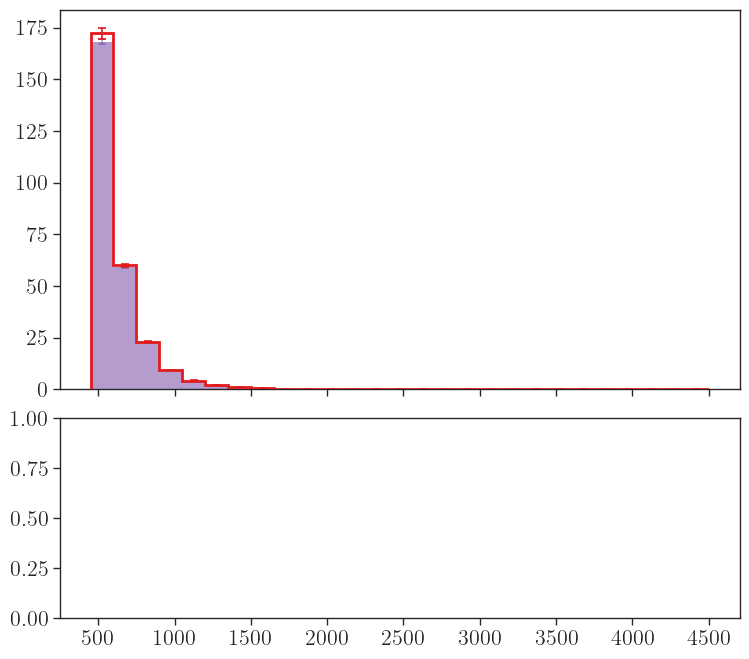

In [15]:
# Setup and Binning
fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

bins = np.arange(450., 4600., 150.)
x = (bins[:-1] + bins[1:]) / 2.0  # Bin centers

##############
#  Main Plot #
##############

models_to_plot = [
    {'data': dists_sm,     'color': sns.color_palette('Paired')[9], 'is_sm': True,  'label': r'$p p \to t\bar{t}$ (SM)'},
    {'data': dists_VLF,    'color': colors[5],                      'is_sm': False, 'label': None},
    {'data': dists_Scalar, 'color': colors[2],                      'is_sm': False, 'label': None},
    {'data': dists_Zp,     'color': colors[1],                      'is_sm': False, 'label': None}
]

h_sm, hErr_sm = None, None
bsm_hists, bsm_errs, bsm_labels, bsm_colors = [], [], [], []

for config in models_to_plot:
    dists = config['data']
    is_sm = config['is_sm']
    color = config['color']
    
    # Define Label
    label = config['label'] if is_sm else rf"{dists['process']} ({dists['model']})"
    
    # Compute histograms and its mc error
    h, _ = np.histogram(dists['mTT'], bins=bins, weights=dists['weights'])
    hErr = np.sqrt(np.histogram(dists['mTT'], bins=bins, weights=np.array(dists['weights'])**2)[0])
    
    # Define Visual Styles 
    alpha  = 0.5 if is_sm else 1.0
    lw     = 0   if is_sm else 2
    fill   = True if is_sm else False
    zorder = 0   if is_sm else 3
    
    # Plot Top Subplot
    axarr[0].hist(bins[:-1], weights=np.abs(h), label=label, bins=bins, 
                  color=color, alpha=alpha, histtype='step', 
                  linewidth=lw, fill=fill, zorder=zorder)
                  
    axarr[0].errorbar(x, np.abs(h), yerr=hErr, color=color, 
                      fmt='none', capsize=3, capthick=1.2, barsabove=True, alpha=alpha)
    
    # Store data for the bottom subplot
    if is_sm:
        h_sm, hErr_sm = h, hErr
    else:
        bsm_hists.append(h)
        bsm_errs.append(hErr)
        bsm_labels.append(label)
        bsm_colors.append(color)


############
#  SUBPLOT #
############
diff = np.array(bsm_hists) - h_sm

#Propagating the errors
diff_err = np.sqrt(np.array(bsm_errs)**2 + hErr_sm**2)

with np.errstate(divide='ignore', invalid='ignore'):
    significance = np.nan_to_num(diff / diff_err) 

for k, sig in enumerate(significance):
    axarr[1].scatter(x, sig, color=bsm_colors[k], label=bsm_labels[k])
    axarr[1].plot(x, sig, color=bsm_colors[k])


#################
#  Plot configs #
#################
# Top Plot
axarr[0].legend(framealpha=1.0, ncol=1, loc='upper right', fontsize=15)
axarr[0].set_yscale('log')
axarr[0].set_ylabel(r'$|\frac{d \sigma}{d m(t\bar{t})}|$ (pb)')
axarr[0].set_xlim(bins.min(), bins.max())

mPsiT = dists_VLF.get('mPsiT', 0)
mSDM  = dists_VLF.get('mSDM', 0)
yDM   = dists_VLF.get('yDM', 0)
axarr[0].set_title(
    (r'$m_{\psi_T} = m_{ST} = %1.0f$ GeV; $m_{s} = m_\chi = %1.0f$ GeV' + '\n' +
     r'$m_{Z^\prime} = %1.1f$ GeV; $\Gamma_{Z^\prime} = %1.1f$ GeV') % 
    (dists_VLF['mPsiT'], dists_VLF['mSDM'], dists_Zp['mZp'], dists_Zp['wZp']), 
    loc='left'
)

# Subplot
axarr[1].axhline(y=0, color='k', linestyle='--') 
axarr[1].set_ylabel(r'$\frac{\left(\frac{d\sigma_{bsm}}{dm(t\bar{t})} - \frac{d\sigma_{sm}}{dm(t\bar{t})}\right)}{Error}$') 
axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)')
axarr[1].grid(True)
axarr[1].set_yticks(np.arange(-3.0, 16.0, 2.0))

plt.tight_layout()
plt.show()

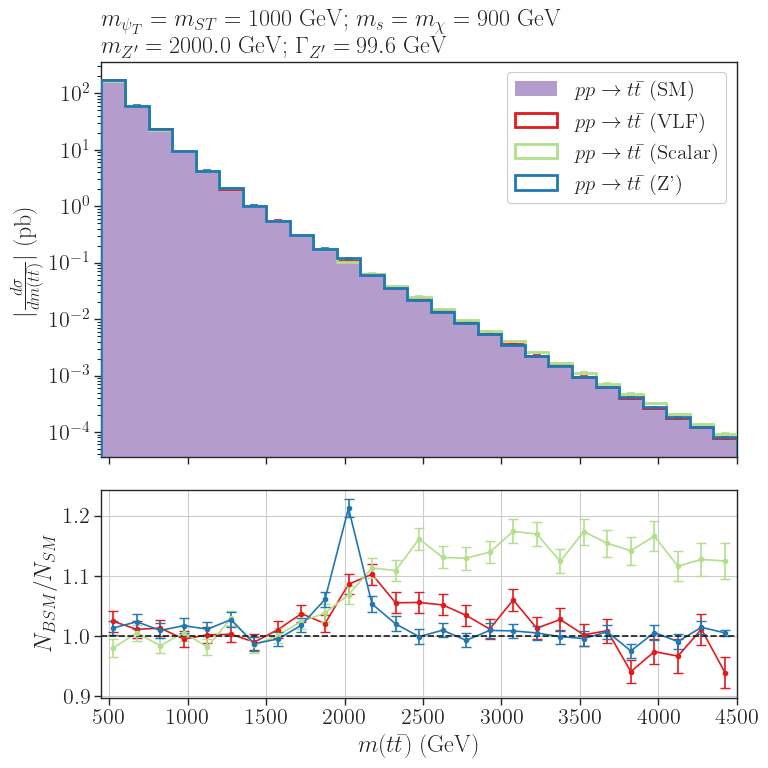

In [ ]:
# --- Setup and Binning ---
fig, axarr = plt.subplots(2, sharex=True, gridspec_kw={'height_ratios': [1.9, 1]}, figsize=(8, 8))
plt.subplots_adjust(left=0.12, bottom=0.12, right=0.97, top=None, wspace=None, hspace=0.1)

bins = np.arange(450., 4600., 150.)
x = (bins[:-1] + bins[1:]) / 2.0  # Bin centers

##############
#  Main Plot #
##############
models_to_plot = [
    {'data': dists_sm,     'color': sns.color_palette('Paired')[9], 'is_sm': True,  'label': r'$p p \to t\bar{t}$ (SM)'},
    {'data': dists_VLF,    'color': colors[5],                      'is_sm': False, 'label': None},
    {'data': dists_Scalar, 'color': colors[2],                      'is_sm': False, 'label': None},
    {'data': dists_Zp,     'color': colors[1],                      'is_sm': False, 'label': None}
]

h_sm, hErr_sm = None, None
bsm_hists, bsm_errs, bsm_labels, bsm_colors = [], [], [], []

for config in models_to_plot:
    dists = config['data']
    is_sm = config['is_sm']
    color = config['color']
    
    # Define Label
    label = config['label'] if is_sm else rf"{dists['process']} ({dists['model']})"
    
    # Compute hitograms
    h, _ = np.histogram(dists['mTT'], bins=bins, weights=dists['weights'])
    hErr = np.sqrt(np.histogram(dists['mTT'], bins=bins, weights=np.array(dists['weights'])**2)[0])
    
    # Define Visual Styles 
    alpha  = 0.5 if is_sm else 1.0
    lw     = 0   if is_sm else 2
    fill   = True if is_sm else False
    zorder = 0   if is_sm else 3
    
    # Plot Top 
    axarr[0].hist(bins[:-1], weights=np.abs(h), label=label, bins=bins, 
                  color=color, alpha=alpha, histtype='step', 
                  linewidth=lw, fill=fill, zorder=zorder)
                  
    axarr[0].errorbar(x, np.abs(h), yerr=hErr, color=color, 
                      fmt='none', capsize=3, capthick=1.2, barsabove=True, alpha=alpha)
    
    # Store data for the bottom subplot
    if is_sm:
        h_sm, hErr_sm = h, hErr
    else:
        bsm_hists.append(h)
        bsm_errs.append(hErr)
        bsm_labels.append(label)
        bsm_colors.append(color)




############
#  SUBPLOT #
############
with np.errstate(divide='ignore', invalid='ignore'):
    # Calculate the ratio BSM / SM
    ratio = np.nan_to_num(np.array(bsm_hists) / h_sm)
    
    # Propagate the errors for the ratio
    err_bsm_rel = np.nan_to_num(np.array(bsm_errs) / np.array(bsm_hists))
    err_sm_rel = np.nan_to_num(hErr_sm / h_sm)
    
    ratio_err = np.abs(ratio) * np.sqrt(err_bsm_rel**2 + err_sm_rel**2)


for k, r in enumerate(ratio):
    # Using errorbar for the ratio points to show the propagated MC uncertainty
    axarr[1].errorbar(x, r, yerr=ratio_err[k], color=bsm_colors[k], fmt='o', ms=3, capsize=3.5, label=bsm_labels[k])
    axarr[1].plot(x, r, color=bsm_colors[k]) # Add a line connecting points


#################
#  Plot configs #
#################
#Upper plot
axarr[0].legend(framealpha=1.0, ncol=1, loc='upper right', fontsize=15)
axarr[0].set_title(
    (r'$m_{\psi_T} = m_{ST} = %1.0f$ GeV; $m_{s} = m_\chi = %1.0f$ GeV' + '\n' +
     r'$m_{Z^\prime} = %1.1f$ GeV; $\Gamma_{Z^\prime} = %1.1f$ GeV') % 
    (dists_VLF['mPsiT'], dists_VLF['mSDM'], dists_Zp['mZp'], dists_Zp['wZp']), 
    loc='left'
)
axarr[0].set_yscale('log')
axarr[0].set_ylabel(r'$|\frac{d \sigma}{d m(t\bar{t})}|$ (pb)')
axarr[0].set_xlim(bins.min(), bins.max())


#Bottom plot
axarr[1].axhline(y=1, color='k', linestyle='--') # Baseline is now at 1
#axarr[1].legend(framealpha=1.0, ncol=2, loc='lower left', fontsize=10)
axarr[1].set_ylabel(r'$N_{BSM} / N_{SM}$') 
axarr[1].set_xlabel(r'$m(t\bar{t})$ (GeV)')
axarr[1].grid(True)



plt.tight_layout()
#filename = f"mtt_qq_mPsiT_{int(mPsiT)}_mSDM_{int(mSDM)}_ratio.png"
#plt.savefig(filename)
plt.show()

## Checking the normalization

We are summing the weights for mtt > 1.5 mPsiT

In [ ]:

mTT_start = 1.5 * mPsiT
tail_mask = bins[:-1] >= mTT_start


tail_sum_NLO = np.sum(bsm_hists[0][tail_mask]) 
tail_sum_S   = np.sum( bsm_hists[1][tail_mask] )
tail_sum_Zp  = np.sum( bsm_hists[2][tail_mask]) 

yDM_S = np.sqrt(7.0**2 * tail_sum_NLO/tail_sum_S)
mu_Zp = np.sqrt(7.0**2 *tail_sum_NLO/tail_sum_Zp)
# Print the results
print(f"--- Sum for mTT >= {mTT_start} GeV ---")
print(f"VLF NLO:      {tail_sum_NLO:.5e}")
print(f"Scalar NLO:   {tail_sum_S:.5e}")
print(f"Z prime:      {tail_sum_Zp:.5e}")
print(f"yDM_S:      {yDM_S:.5e}")
print(f"mu_Z:      {mu_Zp:.5e}")
print()


--- Sum for mTT >= 1500.0 GeV ---
VLF NLO:      1.30675e+00
Scalar NLO:   1.30754e+00
Z prime:      1.30518e+00
yDM_S:      6.99788e+00
mu_Z:      7.00420e+00



In [ ]:
mTT_start = 1.5 * mPsiT
tail_mask = bins[:-1] >= mTT_start


tail_sum_NLO = np.sum(bsm_hists[0][tail_mask]) - np.sum(h_sm[tail_mask]) 
tail_sum_S   = np.sum( bsm_hists[1][tail_mask] )- np.sum(h_sm[tail_mask]) 
tail_sum_Zp  = np.sum( bsm_hists[2][tail_mask]) - np.sum(h_sm[tail_mask]) 

yDM_S = np.sqrt( tail_sum_NLO/tail_sum_S)
mu_Zp = np.sqrt(tail_sum_NLO/tail_sum_Zp)
# Print the results
print(f"--- Sum for mTT >= {mTT_start} GeV ---")
print(f"VLF NLO:      {tail_sum_NLO:.5e}")
print(f"Scalar NLO:   {tail_sum_S:.5e}")
print(f"Z prime:      {tail_sum_Zp:.5e}")
print(f"yDM_S:      {yDM_S:.5e}")
print(f"mu_Z:      {mu_Zp:.5e}")
print()

--- Sum for mTT >= 1500.0 GeV ---
VLF NLO:      3.90611e-02
Scalar NLO:   3.98531e-02
Z prime:      3.74934e-02
yDM_S:      9.90013e-01
mu_Z:      1.02069e+00

